In [1]:
"""
Train a noised image classifier on ImageNet.
"""

import argparse
import os
import sys
from torch.autograd import Variable
sys.path.append("..")
sys.path.append(".")
sys.path.append("./anomaly-detection/diffusion-anomaly")
from guided_diffusion.bratsloader import BRATSDataset
import blobfile as bf
import torch as th
os.environ['OMP_NUM_THREADS'] = '0'
os.environ["PYTORCH_NVML_BASED_CUDA_CHECK"] = "0"

import torch.distributed as dist
import torch.nn.functional as F
from torch.nn.parallel.distributed import DistributedDataParallel as DDP
from torch.optim import AdamW
from visdom import Visdom
import numpy as np
# viz = Visdom(port=8850)
# loss_window = viz.line( Y=th.zeros((1)).cpu(), X=th.zeros((1)).cpu(), opts=dict(xlabel='epoch', ylabel='Loss', title='classification loss'))
# val_window = viz.line( Y=th.zeros((1)).cpu(), X=th.zeros((1)).cpu(), opts=dict(xlabel='epoch', ylabel='Loss', title='validation loss'))
# acc_window= viz.line( Y=th.zeros((1)).cpu(), X=th.zeros((1)).cpu(), opts=dict(xlabel='epoch', ylabel='acc', title='accuracy'))

from guided_diffusion import dist_util, logger
from guided_diffusion.fp16_util import MixedPrecisionTrainer
# from guided_diffusion.image_datasets import load_data
from guided_diffusion.train_util import visualize
from guided_diffusion.resample import create_named_schedule_sampler
from guided_diffusion.script_util import add_dict_to_argparser
from guided_diffusion.script_util import args_to_dict
from guided_diffusion.script_util import classifier_and_diffusion_defaults
from guided_diffusion.script_util import create_classifier_and_diffusion
from guided_diffusion.train_util import parse_resume_step_from_filename, log_loss_dict

In [2]:
import h5py
import glob
from torch.utils.data import Dataset

class LARTPCDataset(Dataset):
    """
    Dataset class for LARTPC H5 files.
    
    H5 file structure:
    - First level keys: data samples (e.g., 'sample_0', 'sample_1', ...)
    - Second level keys: channel names (e.g., 'p1', 'p2', 'p3', 'p4')
    - Each channel: 2D image array
    
    Returns format matching BRATSDataset: (batch, extra, labels, _, _)
    """
    
    def __init__(self, data_dir, test_flag=False, label_key='label', default_label=0):
        """
        Args:
            data_dir: Directory containing H5 files
            test_flag: Whether this is test data (for consistency with BRATSDataset)
            label_key: Key name for labels in H5 file (if labels are stored in H5)
                      If None, will use default_label for all samples
            default_label: Default label value if labels are not in H5 files
        """
        self.data_dir = data_dir
        self.test_flag = test_flag
        self.label_key = label_key
        self.default_label = default_label
        
        # Find all H5 files in the directory
        self.h5_files = sorted(glob.glob(os.path.join(data_dir, '*.h5')))
        if len(self.h5_files) == 0:
            # Also check for .hdf5 extension
            self.h5_files = sorted(glob.glob(os.path.join(data_dir, '*.hdf5')))
        
        if len(self.h5_files) == 0:
            raise ValueError(f"No H5 files found in {data_dir}")
        
        print(f"Found {len(self.h5_files)} H5 files in {data_dir}")
        
        # Build index: (file_idx, sample_key) pairs
        self.samples = []
        self.channel_names = None
        
        for file_idx, h5_file in enumerate(self.h5_files):
            try:
                with h5py.File(h5_file, 'r') as f:
                    # Get all first-level keys (sample names)
                    sample_keys = list(f.keys())
                    # TODO: change this to the actual number of samples per file
                    # sample_keys = sample_keys[:10]  # Take only up to 5 samples from this file
                    
                    # Get channel names from first sample (assuming all samples have same channels)
                    if self.channel_names is None and len(sample_keys) > 0:
                        first_sample = sample_keys[0]
                        self.channel_names = sorted(list(f[first_sample].keys()))
                        print(f"Found channels: {self.channel_names}")
                    
                    # Add all samples from this file
                    for sample_key in sample_keys:
                        self.samples.append((file_idx, sample_key))
            except Exception as e:
                print(f"Warning: Could not read {h5_file}: {e}")
                continue
        
        print(f"Total samples: {len(self.samples)}")
        if self.channel_names:
            print(f"Channels per sample: {len(self.channel_names)}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        """
        Returns:
            image: torch.Tensor of shape [num_channels, H, W]
            extra: dict with metadata
            label: torch.Tensor (scalar)
            _: placeholder (for compatibility)
            _: placeholder (for compatibility)
        """
        file_idx, sample_key = self.samples[idx]
        h5_file = self.h5_files[file_idx]
        
        # Open H5 file and read sample
        with h5py.File(h5_file, 'r') as f:
            sample_data = f[sample_key]

            # Read all channels
            channels = []
            # TODO: change this to the actual channel names
            # for ch_name in self.channel_names:
            channel_names = ['frame_loose_lf0', 'frame_mp2_roi0', 'frame_mp3_roi0']
            for ch_name in channel_names:
                if ch_name in sample_data:
                    channel_data = np.array(sample_data[ch_name])

                    # TODO: crop manually to make images the same square size of 256x256
                    channel_data = channel_data[0:1000, 0:1000]

                    # Ensure it's 2D
                    if channel_data.ndim > 2:
                        channel_data = channel_data.squeeze()
                    if channel_data.ndim != 2:
                        raise ValueError(f"Channel {ch_name} is not 2D: shape {channel_data.shape}")
                    channels.append(channel_data)
                else:
                    raise KeyError(f"Channel {ch_name} not found in sample {sample_key}")
            
            # Stack channels: [num_channels, H, W]
            image = np.stack(channels, axis=0)
            
            # Get label if available
            if self.label_key and self.label_key in sample_data:
                label = int(sample_data[self.label_key][()])
            elif self.label_key and self.label_key in f:
                # Label might be at file level
                label = int(f[self.label_key][()])
            else:
                label = self.default_label
        
        # Convert to torch tensor
        image = th.from_numpy(image).float()
        label = th.tensor(label, dtype=th.long)
        
        # Create extra dict (for compatibility with BRATSDataset format)
        extra = {
            'file': h5_file,
            'sample_key': sample_key,
            'channels': self.channel_names
        }
        
        # Return empty tensors instead of None to avoid collate errors
        return image, extra, label, th.tensor([]), th.tensor([])

In [3]:
class LARTPCDatasetPlanes(Dataset):
    """
    Dataset class for LARTPC H5 files.
    
    H5 file structure:
    - First level keys: data samples (e.g., 'sample_0', 'sample_1', ...)
    - Second level keys: channel names (e.g., 'p1', 'p2', 'p3', 'p4')
    - Each channel: 2D image array
    
    Returns format matching BRATSDataset: (batch, extra, labels, _, _)
    """
    
    def __init__(self, data_dir, test_flag=False, label_key='label', default_label=0):
        """
        Args:
            data_dir: Directory containing H5 files
            test_flag: Whether this is test data (for consistency with BRATSDataset)
            label_key: Key name for labels in H5 file (if labels are stored in H5)
                      If None, will use default_label for all samples
            default_label: Default label value if labels are not in H5 files
        """
        self.data_dir = data_dir
        self.test_flag = test_flag
        self.label_key = label_key
        self.default_label = default_label
        
        # Find all H5 files in the directory
        self.h5_files = sorted(glob.glob(os.path.join(data_dir, '*.h5')))
        if len(self.h5_files) == 0:
            # Also check for .hdf5 extension
            self.h5_files = sorted(glob.glob(os.path.join(data_dir, '*.hdf5')))
        
        if len(self.h5_files) == 0:
            raise ValueError(f"No H5 files found in {data_dir}")
        
        print(f"Found {len(self.h5_files)} H5 files in {data_dir}")
        
        # Build index: (file_idx, sample_key) pairs
        self.samples = []
        self.channel_names = None
        
        for file_idx, h5_file in enumerate(self.h5_files):
            try:
                with h5py.File(h5_file, 'r') as f:
                    # Get all first-level keys (sample names)
                    sample_keys = list(f.keys())
                    # TODO: change this to the actual number of samples per file
                    # sample_keys = sample_keys[:10]  # Take only up to 5 samples from this file
                    
                    # Get channel names from first sample (assuming all samples have same channels)
                    if self.channel_names is None and len(sample_keys) > 0:
                        first_sample = sample_keys[0]
                        self.channel_names = sorted(list(f[first_sample].keys()))
                        print(f"Found channels: {self.channel_names}")
                    
                    # Add all samples from this file
                    for sample_key in sample_keys:
                        self.samples.append((file_idx, sample_key))
            except Exception as e:
                print(f"Warning: Could not read {h5_file}: {e}")
                continue
        
        print(f"Total samples: {len(self.samples)}")
        if self.channel_names:
            print(f"Channels per sample: {len(self.channel_names)}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        """
        Returns:
            image: torch.Tensor of shape [num_channels, H, W]
            extra: dict with metadata
            label: torch.Tensor (scalar)
            _: placeholder (for compatibility)
            _: placeholder (for compatibility)
        """
        file_idx, sample_key = self.samples[idx]
        h5_file = self.h5_files[file_idx]
        
        # Open H5 file and read sample
        with h5py.File(h5_file, 'r') as f:
            sample_data = f[sample_key]

            # Read all channels
            channels = []
            # TODO: change this to the actual channel names
            # for ch_name in self.channel_names:
            channel_names = ['plane0', 'plane1', 'plane2']
            self.channel_names = ['plane0', 'plane1', 'plane2']
            planes = [0, 1, 2]
            for plane in planes:
                ch_name = 'frame_loose_lf0'
                if ch_name in sample_data:
                    channel_data = np.array(sample_data[ch_name][1984*plane:1984*(plane+1), :])

                    # TODO: crop manually to make images the same square size of 256x256
                    channel_data = channel_data[0:1000, 0:1000]

                    # Ensure it's 2D
                    if channel_data.ndim > 2:
                        channel_data = channel_data.squeeze()
                    if channel_data.ndim != 2:
                        raise ValueError(f"Channel {ch_name} is not 2D: shape {channel_data.shape}")
                    channels.append(channel_data)
                else:
                    raise KeyError(f"Channel {ch_name} not found in sample {sample_key}")
            
            # Stack channels: [num_channels, H, W]
            image = np.stack(channels, axis=0)
            
            # Get label if available
            if self.label_key and self.label_key in sample_data:
                label = int(sample_data[self.label_key][()])
            elif self.label_key and self.label_key in f:
                # Label might be at file level
                label = int(f[self.label_key][()])
            else:
                label = self.default_label
        
        # Convert to torch tensor
        image = th.from_numpy(image).float()
        label = th.tensor(label, dtype=th.long)
        
        # Create extra dict (for compatibility with BRATSDataset format)
        extra = {
            'file': h5_file,
            'sample_key': sample_key,
            'channels': channel_names
        }
        
        # Return empty tensors instead of None to avoid collate errors
        return image, extra, label, th.tensor([]), th.tensor([])

In [4]:
def train():
    # args = create_argparser().parse_args()
    args = argparse.Namespace(**defaults)

    dist_util.setup_dist()
    logger.configure()

    logger.log("creating model and diffusion...")
    model, diffusion = create_classifier_and_diffusion(
        **args_to_dict(argparse.Namespace(**defaults), classifier_and_diffusion_defaults().keys()),
    )
    model.to(dist_util.dev())
    # model.to('cpu')
    if args.noised:
        schedule_sampler = create_named_schedule_sampler(
            args.schedule_sampler, diffusion, maxt=1000
        )

    resume_step = 0
    if args.resume_checkpoint:
        resume_step = parse_resume_step_from_filename(args.resume_checkpoint)
        if dist.get_rank() == 0:
            logger.log(
                f"loading model from checkpoint: {args.resume_checkpoint}... at {resume_step} step"
            )
            model.load_state_dict(
                dist_util.load_state_dict(
                    args.resume_checkpoint, map_location=dist_util.dev()
                )
            )

    # Needed for creating correct EMAs and fp16 parameters.
    dist_util.sync_params(model.parameters())

    mp_trainer = MixedPrecisionTrainer(
        model=model, use_fp16=args.classifier_use_fp16, initial_lg_loss_scale=16.0
    )


    logger.log("creating data loader...")

    if args.dataset == 'brats':
        ds = BRATSDataset(args.data_dir, test_flag=False)
        datal = th.utils.data.DataLoader(
            ds,
            batch_size=args.batch_size,
            shuffle=True)
        data = iter(datal)

    elif args.dataset == 'lartpc':
        ds = LARTPCDataset(args.data_dir, test_flag=False)
        datal = th.utils.data.DataLoader(
            ds,
            batch_size=args.batch_size,
            shuffle=True)
        data = iter(datal)
        print('dataset is lartpc')

    elif args.dataset == 'chexpert':
        data = load_data(
            data_dir=args.data_dir,
            batch_size=args.batch_size,
            image_size=args.image_size,
            class_cond=True,
        )
        print('dataset is chexpert')



    logger.log(f"creating optimizer...")
    opt = AdamW(mp_trainer.master_params, lr=args.lr, weight_decay=args.weight_decay)
    if args.resume_checkpoint:
        opt_checkpoint = bf.join(
            bf.dirname(args.resume_checkpoint), f"opt{resume_step:06}.pt"
        )
        logger.log(f"loading optimizer state from checkpoint: {opt_checkpoint}")
        opt.load_state_dict(
            dist_util.load_state_dict(opt_checkpoint, map_location=dist_util.dev())
        )

    logger.log("training classifier model...")


    def forward_backward_log(data_loader, step, prefix="train"):
        if args.dataset=='brats':
            batch, extra, labels,_ , _ = next(data_loader)
            print('IS BRATS')

        elif args.dataset=='lartpc':
            batch, extra, labels, _, _ = next(data_loader)
            print('IS LARTPC')

        elif  args.dataset=='chexpert':
            batch, extra = next(data_loader)
            labels = extra["y"].to(dist_util.dev())
            print('IS CHEXPERT')

        print('labels', labels)
        batch = batch.to(dist_util.dev())
        labels= labels.to(dist_util.dev())
        if args.noised:
            t, _ = schedule_sampler.sample(batch.shape[0], dist_util.dev())
            batch = diffusion.q_sample(batch, t)
        else:
            t = th.zeros(batch.shape[0], dtype=th.long, device=dist_util.dev())

        for i, (sub_batch, sub_labels, sub_t) in enumerate(
            split_microbatches(args.microbatch, batch, labels, t)
        ):
          
            sub_batch = Variable(sub_batch, requires_grad=True)
            # logits = model(sub_batch, timesteps=sub_t)
            try:
                logits = model(sub_batch, timesteps=sub_t)
            except RuntimeError as e:
                print(f"CUDA error: {e}. Trying on CPU instead.")
                sub_batch_cpu = sub_batch.cpu()
                sub_t_cpu = sub_t.cpu()
                model_cpu = model.to('cpu')
                logits = model_cpu(sub_batch_cpu, timesteps=sub_t_cpu)

                # Move model back to original device (optional, if used in a loop)
                model.to(dist_util.dev())
                # move logits to original device
                logits = logits.to(dist_util.dev())
                sub_batch = Variable(sub_batch_cpu.to(dist_util.dev()), requires_grad=True)
         
            loss = F.cross_entropy(logits, sub_labels, reduction="none")
            losses = {}
            losses[f"{prefix}_loss"] = loss.detach()
            losses[f"{prefix}_acc@1"] = compute_top_k(
                logits, sub_labels, k=1, reduction="none"
            )
            losses[f"{prefix}_acc@2"] = compute_top_k(
                logits, sub_labels, k=2, reduction="none"
            )
            print('acc', losses[f"{prefix}_acc@1"])
            log_loss_dict(diffusion, sub_t, losses)

            loss = loss.mean()
            if prefix=="train":
                print("train")
                # viz.line(X=th.ones((1, 1)).cpu() * step, Y=th.Tensor([loss]).unsqueeze(0).cpu(),
                #      win=loss_window, name='loss_cls',
                #      update='append')

            else:

                output_idx = logits[0].argmax()
                print('outputidx', output_idx)
                output_max = logits[0, output_idx]
                print('outmax', output_max, output_max.shape)
                output_max.backward()
                saliency, _ = th.max(sub_batch.grad.data.abs(), dim=1)
                print('saliency', saliency.shape)
                # viz.heatmap(visualize(saliency[0, ...]))
                # viz.image(visualize(sub_batch[0, 0,...]))
                # viz.image(visualize(sub_batch[0, 1, ...]))
                th.cuda.empty_cache()


            if loss.requires_grad and prefix=="train":
                if i == 0:
                    mp_trainer.zero_grad()

                #TODO: device match error
                # mp_trainer.backward(loss * len(sub_batch) / len(batch))

        return losses

    correct=0; total=0
    for step in range(args.iterations - resume_step):
        logger.logkv("step", step + resume_step)
        logger.logkv(
            "samples",
            (step + resume_step + 1) * args.batch_size * dist.get_world_size(),
        )
        if args.anneal_lr:
            set_annealed_lr(opt, args.lr, (step + resume_step) / args.iterations)
        print('step', step + resume_step)
        try:
            losses = forward_backward_log(data, step + resume_step)
        except:
            data = iter(datal)
            losses = forward_backward_log(data, step + resume_step)

        correct+=losses["train_acc@1"].sum()
        total+=args.batch_size
        acctrain=correct/total

        mp_trainer.optimize(opt)
          
        if not step % args.log_interval:
            logger.dumpkvs()
        if (
            step
            and dist.get_rank() == 0
            and not (step + resume_step) % args.save_interval
        ):
            logger.log("saving model...")
            save_model(mp_trainer, opt, step + resume_step)

    if dist.get_rank() == 0:
        logger.log("saving model...")
        save_model(mp_trainer, opt, step + resume_step)
    dist.barrier()

In [5]:
def set_annealed_lr(opt, base_lr, frac_done):
    lr = base_lr * (1 - frac_done)
    for param_group in opt.param_groups:
        param_group["lr"] = lr


def save_model(mp_trainer, opt, step):
    if dist.get_rank() == 0:
        th.save(
            mp_trainer.master_params_to_state_dict(mp_trainer.master_params),
            os.path.join(logger.get_dir(), f"modelbratsclass{step:06d}.pt"),
        )
        th.save(opt.state_dict(), os.path.join(logger.get_dir(), f"optbratsclass{step:06d}.pt"))

def compute_top_k(logits, labels, k, reduction="mean"):
    _, top_ks = th.topk(logits, k, dim=-1)
    if reduction == "mean":
        return (top_ks == labels[:, None]).float().sum(dim=-1).mean().item()
    elif reduction == "none":
        return (top_ks == labels[:, None]).float().sum(dim=-1)

def split_microbatches(microbatch, *args):
    bs = len(args[0])
    if microbatch == -1 or microbatch >= bs:
        yield tuple(args)
    else:
        for i in range(0, bs, microbatch):
            yield tuple(x[i : i + microbatch] if x is not None else None for x in args)

In [6]:
defaults = dict(
    data_dir = "/home/munjung/anomaly-detection/diffusion-anomaly/data/brats/training",
    val_data_dir = "/home/munjung/anomaly-detection/diffusion-anomaly/data/brats/testing", 
    noised=True,
    iterations=150000,
    lr=3e-4,
    weight_decay=0.0,
    anneal_lr=False,
    batch_size=4,
    microbatch=-1,
    schedule_sampler="uniform",
    resume_checkpoint="",
    log_interval=1,
    eval_interval=1000,
    save_interval=5000,
    dataset='brats',
    image_size = 256,
    classifier_attention_resolutions = (32,16,8),
    classifier_depth = 4,
    classifier_width = 32,
    classifier_pool = "attention",
    classifier_resblock_updown = True,
    classifier_use_scale_shift_norm = True
)
defaults.update(classifier_and_diffusion_defaults())

In [7]:
train()

Logging to ./results
creating model and diffusion...
timestepresp2 
number_in_channels classifier 4
pool spatial
spatial
steps 1000 [1000]
num_timesteps 1000
sectioncount [1000]
all steps {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 1

: 

# Inspect some samples

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [10]:
def visualize_brats_samples(dataset, num_samples=4, num_examples_per_sample=1):
    # Create a DataLoader to get batches
    dataloader = th.utils.data.DataLoader(
        dataset,
        batch_size=num_samples,
        shuffle=True
    )
    
    # Get one batch
    batch, extra, labels, _, _ = next(iter(dataloader))
    
    if dataset=='brats':
        channel_names = ['T1', 'T1CE', 'T2', 'FLAIR']
    channel_names = ['T1', 'T1CE', 'T2', 'FLAIR']
    
    # Determine how many samples to show
    n_samples = min(num_samples, batch.shape[0])
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 5 * n_samples))
    gs = gridspec.GridSpec(n_samples, 5, figure=fig, hspace=0.3, wspace=0.3)
    
    for sample_idx in range(n_samples):
        sample = batch[sample_idx]  # Shape: [4, H, W]
        label = labels[sample_idx].item()
        
        # Plot each channel
        for ch_idx in range(4):
            ax = fig.add_subplot(gs[sample_idx, ch_idx])
            channel_data = sample[ch_idx].numpy()
            
            # Normalize for visualization
            vmin = channel_data.min()
            vmax = channel_data.max()
            if vmax > vmin:
                channel_data = (channel_data - vmin) / (vmax - vmin)
            
            im = ax.imshow(channel_data, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'{channel_names[ch_idx]}', fontsize=12, fontweight='bold')
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046)
        
        # Plot all channels combined (RGB-like, using first 3 channels)
        ax = fig.add_subplot(gs[sample_idx, 4])
        # Create a composite image from the 4 channels
        # Normalize each channel
        composite = []
        for ch_idx in range(4):
            ch_data = sample[ch_idx].numpy()
            vmin, vmax = ch_data.min(), ch_data.max()
            if vmax > vmin:
                ch_data = (ch_data - vmin) / (vmax - vmin)
            composite.append(ch_data)
        
        # Stack channels (use first 3 for RGB visualization)
        composite_rgb = np.stack([composite[0], composite[1], composite[2]], axis=-1)
        ax.imshow(composite_rgb)
        ax.set_title(f'Composite (Label: {label})', fontsize=12, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle('BRATS Dataset Samples - 4 Channels (T1, T1CE, T2, FLAIR)', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nBatch Statistics:")
    print(f"  Batch shape: {batch.shape}")
    print(f"  Labels: {labels.numpy()}")
    print(f"  Label distribution: {dict(zip(*np.unique(labels.numpy(), return_counts=True)))}")
    print(f"  Pixel value range: [{batch.min().item():.3f}, {batch.max().item():.3f}]")
    print(f"  Mean pixel value: {batch.mean().item():.3f}")
    print(f"  Std pixel value: {batch.std().item():.3f}")

Loading dataset for visualization...
Dataset size: 4

Visualizing sample inputs:


/tmp/ipykernel_7708/1930353762.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


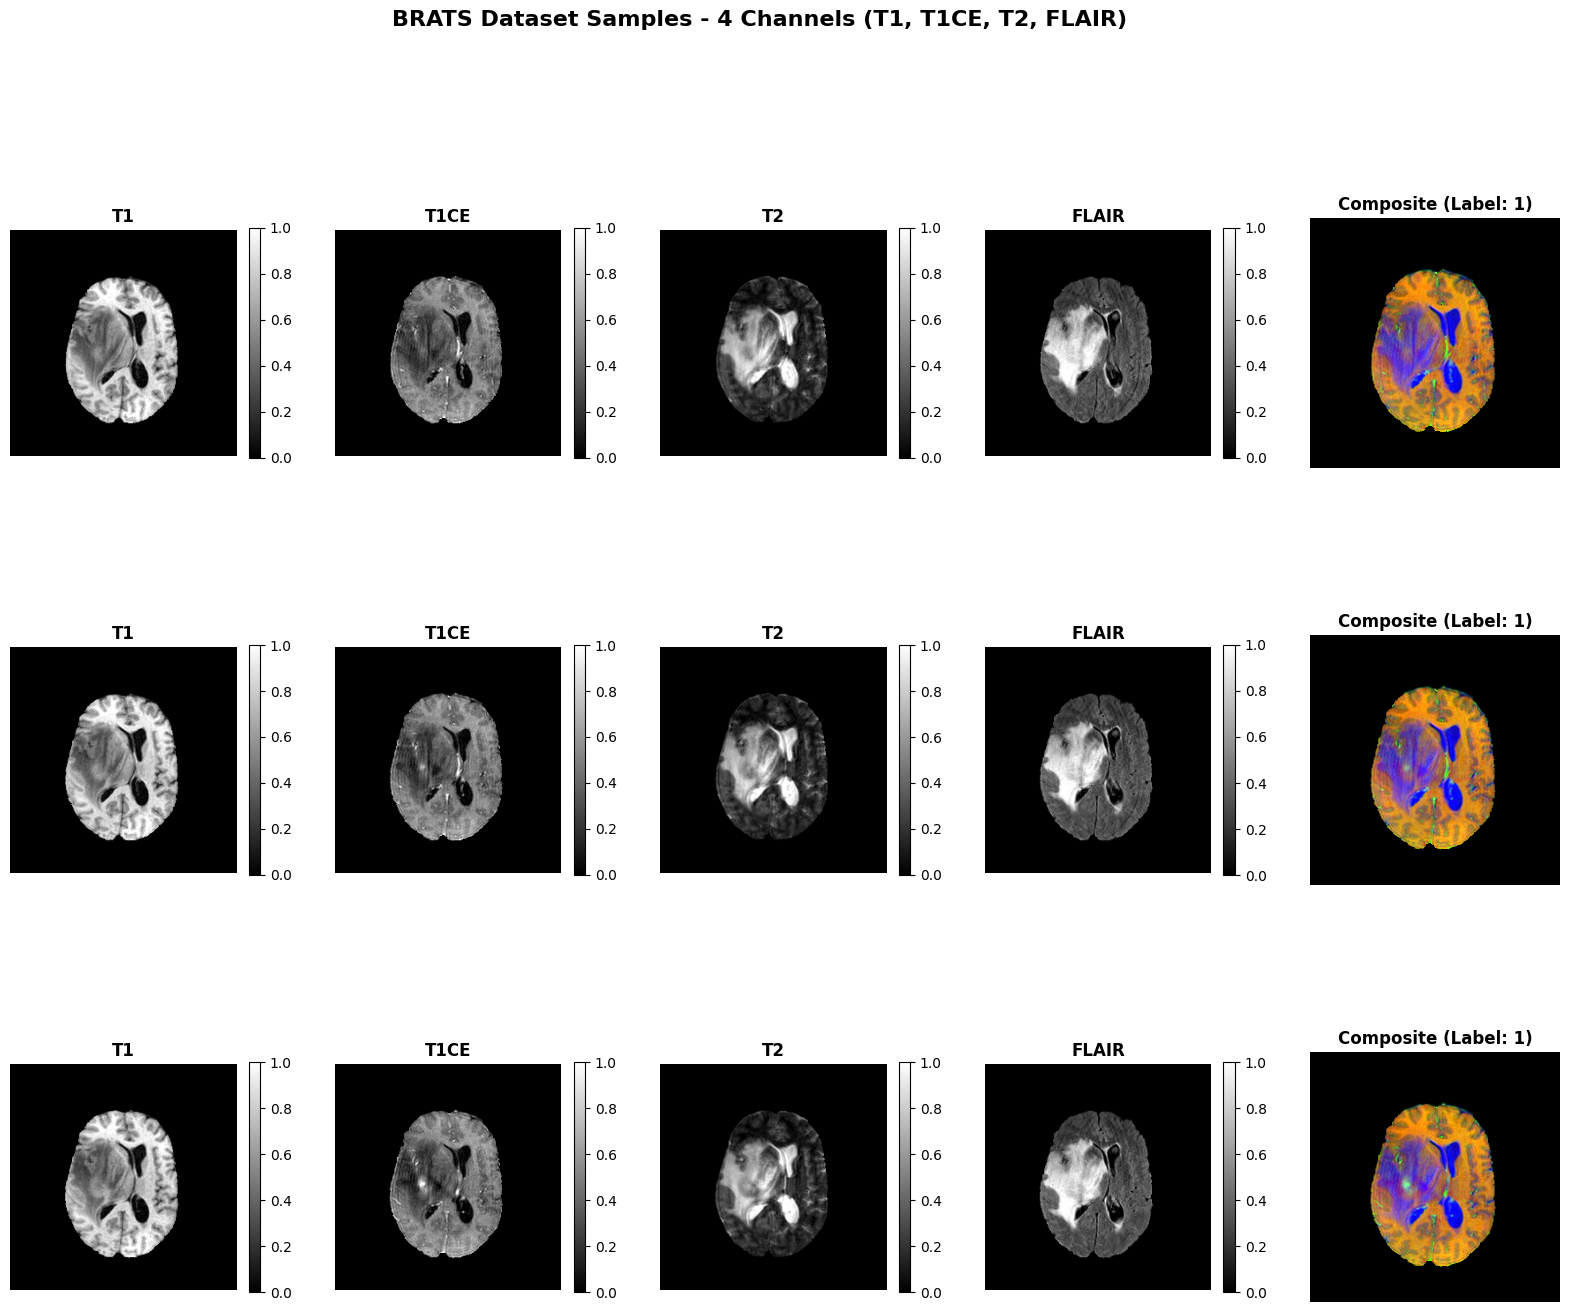


Batch Statistics:
  Batch shape: torch.Size([3, 4, 256, 256])
  Labels: [1 1 1]
  Label distribution: {np.int64(1): np.int64(3)}
  Pixel value range: [0.000, 1.000]
  Mean pixel value: 0.116
  Std pixel value: 0.233


In [11]:
# Visualize examples
print("Loading dataset for visualization...")
ds = BRATSDataset(defaults['data_dir'], test_flag=False)
print(f"Dataset size: {len(ds)}")
print("\nVisualizing sample inputs:")
visualize_brats_samples(ds, num_samples=3)

In [12]:
def visualize_lartpc_samples(dataset, num_samples=4, num_examples_per_sample=1):
    """
    Visualize LARTPC dataset samples.
    
    Args:
        dataset: LARTPCDataset instance
        num_samples: Number of different samples to visualize
        num_examples_per_sample: Number of examples per sample (if batch_size > 1)
    """
    # Create a DataLoader to get batches
    dataloader = th.utils.data.DataLoader(
        dataset,
        batch_size=num_samples,
        shuffle=True
    )
    
    # Get one batch
    batch, extra, labels, _, _ = next(iter(dataloader))
    # print("extra",batch.shape)
    
    # Get actual number of channels from batch shape
    num_channels = batch.shape[1]
    
    # Get channel names from the dataset or from extra dict
    if hasattr(dataset, 'channel_names') and dataset.channel_names:
        channel_names = dataset.channel_names[:num_channels]  # Truncate to match actual channels
    elif len(extra) > 0 and 'channels' in extra[0]:
        channel_names = extra[0]['channels'][:num_channels]  # Truncate to match actual channels
    else:
        # Fallback: use generic names
        channel_names = [f'ch_{i}' for i in range(num_channels)]
    
    # Determine how many samples to show
    n_samples = min(num_samples, batch.shape[0])
    
    # Create figure with subplots: num_channels + 1 (for composite)
    fig = plt.figure(figsize=(4 * (num_channels + 1), 5 * n_samples))
    gs = gridspec.GridSpec(n_samples, num_channels + 1, figure=fig, hspace=0.3, wspace=0.3)
    
    for sample_idx in range(n_samples):
        sample = batch[sample_idx]  # Shape: [num_channels, H, W]
        label = labels[sample_idx].item()
        
        # Plot each channel
        for ch_idx in range(num_channels):
            ax = fig.add_subplot(gs[sample_idx, ch_idx])
            channel_data = sample[ch_idx].numpy()
            
            # Normalize for visualization
            vmin = channel_data.min()
            vmax = channel_data.max()
            if vmax > vmin:
                channel_data = (channel_data - vmin) / (vmax - vmin)
            
            im = ax.imshow(channel_data, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'{channel_names[ch_idx]}', fontsize=12, fontweight='bold')
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046)
        
        # Plot all channels combined (RGB-like, using first 3 channels if available)
        ax = fig.add_subplot(gs[sample_idx, num_channels])
        # Create a composite image from the channels
        # Normalize each channel
        composite = []
        for ch_idx in range(num_channels):
            ch_data = sample[ch_idx].numpy()
            vmin, vmax = ch_data.min(), ch_data.max()
            if vmax > vmin:
                ch_data = (ch_data - vmin) / (vmax - vmin)
            composite.append(ch_data)
        
        # Stack channels for RGB visualization
        if num_channels >= 3:
            # Use first 3 channels for RGB
            composite_rgb = np.stack([composite[0], composite[1], composite[2]], axis=-1)
        elif num_channels == 2:
            # Use 2 channels + zero channel for RGB
            composite_rgb = np.stack([composite[0], composite[1], np.zeros_like(composite[0])], axis=-1)
        else:
            # Single channel: convert to grayscale RGB
            composite_rgb = np.stack([composite[0], composite[0], composite[0]], axis=-1)
        
        ax.imshow(composite_rgb)
        ax.set_title(f'Composite (Label: {label})', fontsize=12, fontweight='bold')
        ax.axis('off')
    
    channel_names_str = ', '.join(channel_names)
    plt.suptitle(f'LARTPC Dataset Samples - {num_channels} Channels ({channel_names_str})', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nBatch Statistics:")
    print(f"  Batch shape: {batch.shape}")
    print(f"  Number of channels: {num_channels}")
    print(f"  Channel names: {channel_names}")
    print(f"  Labels: {labels.numpy()}")
    print(f"  Label distribution: {dict(zip(*np.unique(labels.numpy(), return_counts=True)))}")
    print(f"  Pixel value range: [{batch.min().item():.3f}, {batch.max().item():.3f}]")
    print(f"  Mean pixel value: {batch.mean().item():.3f}")
    print(f"  Std pixel value: {batch.std().item():.3f}")


In [13]:
def visualize_chexpert_samples(data_loader, num_samples=4):
    """
    Visualize CheXpert dataset samples.
    
    Args:
        data_loader: DataLoader iterator for CheXpert dataset
                     Returns (batch, extra) where labels = extra["y"]
        num_samples: Number of different samples to visualize
    """
    # Get one batch from the data loader
    batch, extra = next(iter(data_loader))
    labels = extra["y"]
    
    print(f"Batch shape: {batch.shape}")
    print(f"Labels shape: {labels.shape}")
    
    # Get actual number of channels from batch shape
    # CheXpert images are typically [batch, channels, H, W]
    if len(batch.shape) == 4:
        num_channels = batch.shape[1]
    else:
        num_channels = 1
    
    # Determine how many samples to show
    n_samples = min(num_samples, batch.shape[0])
    
    # Create figure with subplots
    # For single channel: show original + maybe a processed version
    # For multi-channel: show each channel
    cols = num_channels + 1 if num_channels > 1 else 2
    fig = plt.figure(figsize=(4 * cols, 5 * n_samples))
    gs = gridspec.GridSpec(n_samples, cols, figure=fig, hspace=0.3, wspace=0.3)
    
    for sample_idx in range(n_samples):
        sample = batch[sample_idx]  # Shape: [channels, H, W] or [H, W]
        label = labels[sample_idx].item() if labels.dim() > 0 else labels.item()
        
        # Handle different tensor shapes
        if sample.dim() == 2:
            # Single channel: [H, W]
            sample = sample.unsqueeze(0)  # Add channel dimension: [1, H, W]
            num_channels = 1
        
        # Plot each channel
        for ch_idx in range(num_channels):
            ax = fig.add_subplot(gs[sample_idx, ch_idx])
            channel_data = sample[ch_idx].cpu().numpy()
            
            # Normalize for visualization
            vmin = channel_data.min()
            vmax = channel_data.max()
            if vmax > vmin:
                channel_data = (channel_data - vmin) / (vmax - vmin)
            
            im = ax.imshow(channel_data, cmap='gray', vmin=0, vmax=1)
            channel_name = f'Channel {ch_idx}' if num_channels > 1 else 'Chest X-ray'
            ax.set_title(f'{channel_name} (Label: {label})', fontsize=12, fontweight='bold')
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046)
        
        # For single channel, show the same image again (or a processed version)
        if num_channels == 1:
            ax = fig.add_subplot(gs[sample_idx, 1])
            channel_data = sample[0].cpu().numpy()
            vmin = channel_data.min()
            vmax = channel_data.max()
            if vmax > vmin:
                channel_data = (channel_data - vmin) / (vmax - vmin)
            im = ax.imshow(channel_data, cmap='viridis', vmin=0, vmax=1)
            ax.set_title(f'Alternative View (Label: {label})', fontsize=12, fontweight='bold')
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046)
        else:
            # Plot composite RGB image (using first 3 channels if available)
            ax = fig.add_subplot(gs[sample_idx, num_channels])
            composite = []
            for ch_idx in range(min(num_channels, 3)):
                ch_data = sample[ch_idx].cpu().numpy()
                vmin, vmax = ch_data.min(), ch_data.max()
                if vmax > vmin:
                    ch_data = (ch_data - vmin) / (vmax - vmin)
                composite.append(ch_data)
            
            # Stack channels for RGB visualization
            if len(composite) >= 3:
                composite_rgb = np.stack([composite[0], composite[1], composite[2]], axis=-1)
            elif len(composite) == 2:
                composite_rgb = np.stack([composite[0], composite[1], np.zeros_like(composite[0])], axis=-1)
            else:
                composite_rgb = np.stack([composite[0], composite[0], composite[0]], axis=-1)
            
            ax.imshow(composite_rgb)
            ax.set_title(f'Composite RGB (Label: {label})', fontsize=12, fontweight='bold')
            ax.axis('off')
    
    plt.suptitle(f'CheXpert Dataset Samples - {num_channels} Channel(s)', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nBatch Statistics:")
    print(f"  Batch shape: {batch.shape}")
    print(f"  Number of channels: {num_channels}")
    print(f"  Labels: {labels.cpu().numpy()}")
    if labels.dim() > 0:
        print(f"  Label distribution: {dict(zip(*np.unique(labels.cpu().numpy(), return_counts=True)))}")
    print(f"  Pixel value range: [{batch.min().item():.3f}, {batch.max().item():.3f}]")
    print(f"  Mean pixel value: {batch.mean().item():.3f}")
    print(f"  Std pixel value: {batch.std().item():.3f}")

In [14]:
from guided_diffusion.image_datasets import load_data

data = load_data(
    data_dir='/home/munjung/anomaly-detection/diffusion-anomaly/data/chexpert/training/healthy',
    batch_size=4,
    image_size=defaults['image_size'],
    class_cond=True,
)

visualize_chexpert_samples(data, num_samples=4)

classnames ['anomaly-detection', 'anomaly-detection', 'anomaly-detection']
len 3
len 3
len 3
lenloader 0


len 3
len 3
len 3



libgomp: Invalid value for environment variable OMP_NUM_THREADS


len 3
len 3
len 3



libgomp: Invalid value for environment variable OMP_NUM_THREADS


...

len 3
len 3
len 3



libgomp: Invalid value for environment variable OMP_NUM_THREADS


len 3
len 3
len 3



libgomp: Invalid value for environment variable OMP_NUM_THREADS


KeyboardInterrupt: 

Loading LARTPC dataset for visualization...
Found 1 H5 files in /scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb/25801404_1
Found channels: ['channels_loose_lf0', 'channels_mp2_roi0', 'channels_mp3_roi0', 'frame_loose_lf0', 'frame_mp2_roi0', 'frame_mp3_roi0', 'tickinfo_loose_lf0', 'tickinfo_mp2_roi0', 'tickinfo_mp3_roi0']
Total samples: 20
Channels per sample: 9
Dataset size: 20

Visualizing sample inputs:


/tmp/ipykernel_4850/3354174096.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


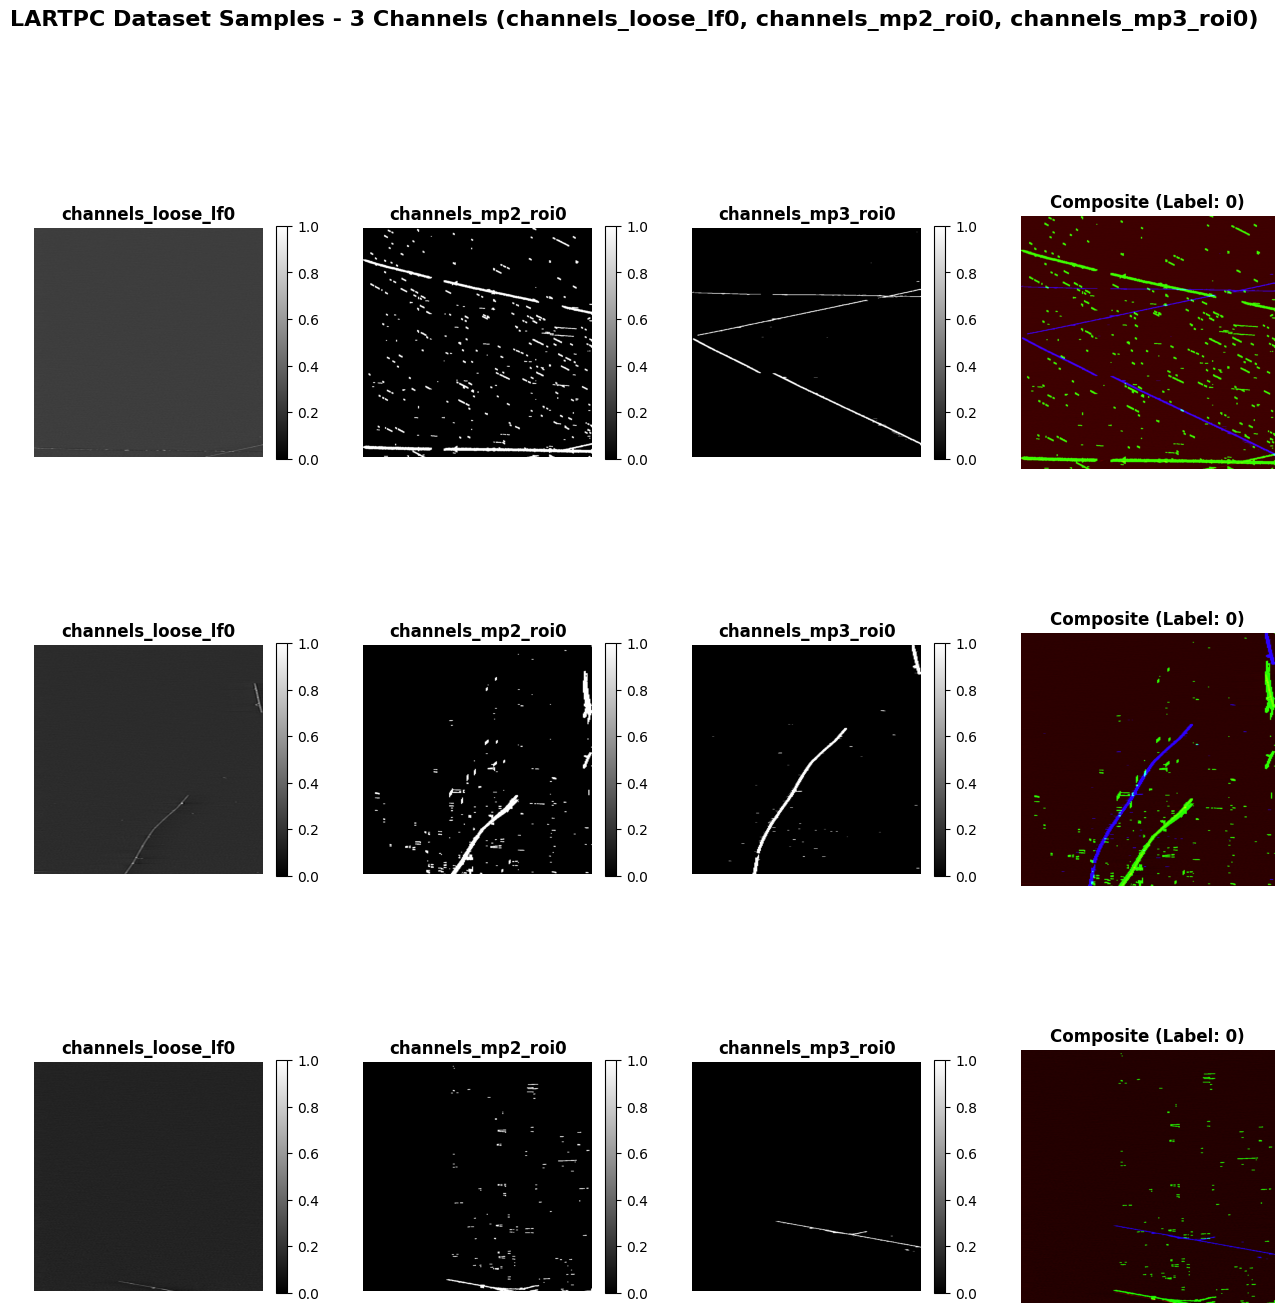


Batch Statistics:
  Batch shape: torch.Size([3, 3, 1000, 1000])
  Number of channels: 3
  Channel names: ['channels_loose_lf0', 'channels_mp2_roi0', 'channels_mp3_roi0']
  Labels: [0 0 0]
  Label distribution: {np.int64(0): np.int64(3)}
  Pixel value range: [-3193.592, 9987.391]
  Mean pixel value: 54.207
  Std pixel value: 470.325


In [ ]:
# Example usage (uncomment to use):
print("Loading LARTPC dataset for visualization...")
lartpc_dir = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb/25801404_1"
ds_lartpc = LARTPCDataset(lartpc_dir, test_flag=False)
print(f"Dataset size: {len(ds_lartpc)}")
print("\nVisualizing sample inputs:")
visualize_lartpc_samples(ds_lartpc, num_samples=3)

Loading LARTPC dataset for visualization...
Found 1 H5 files in /scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb/25801404_1
Found channels: ['channels_loose_lf0', 'channels_mp2_roi0', 'channels_mp3_roi0', 'frame_loose_lf0', 'frame_mp2_roi0', 'frame_mp3_roi0', 'tickinfo_loose_lf0', 'tickinfo_mp2_roi0', 'tickinfo_mp3_roi0']
Total samples: 20
Channels per sample: 9
Dataset size: 20

Visualizing sample inputs:


/tmp/ipykernel_4850/3354174096.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


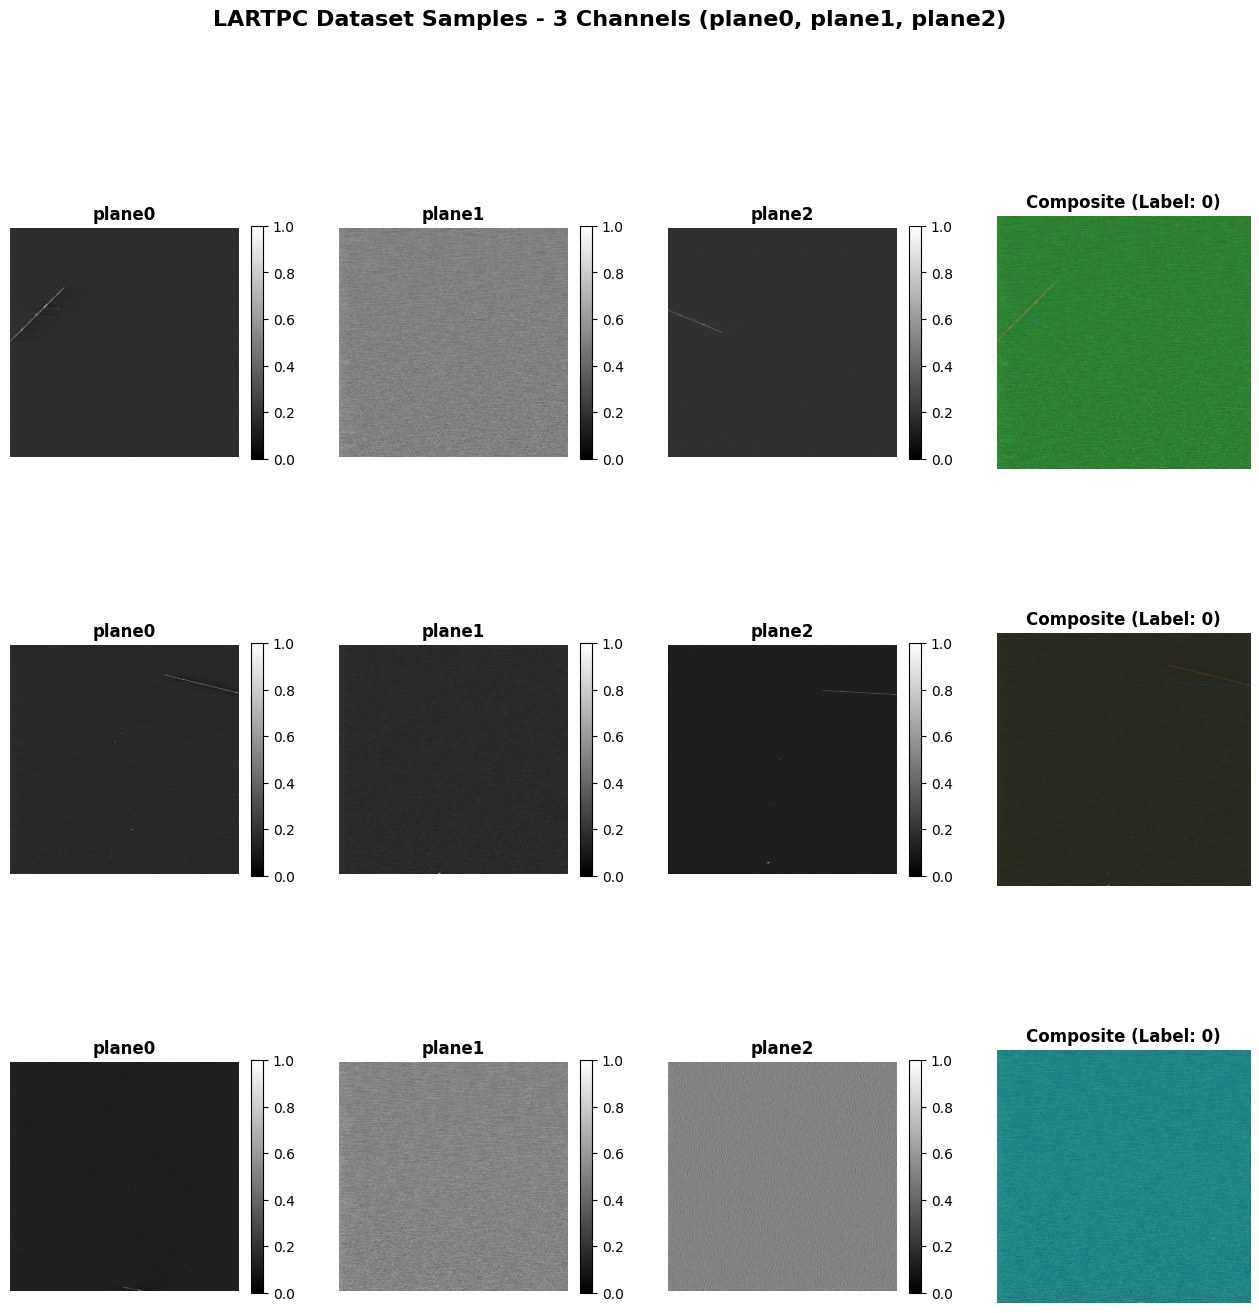


Batch Statistics:
  Batch shape: torch.Size([3, 3, 1000, 1000])
  Number of channels: 3
  Channel names: ['plane0', 'plane1', 'plane2']
  Labels: [0 0 0]
  Label distribution: {np.int64(0): np.int64(3)}
  Pixel value range: [-7071.477, 29720.393]
  Mean pixel value: 4.958
  Std pixel value: 236.703


In [ ]:
# Example usage (uncomment to use):
print("Loading LARTPC dataset for visualization...")
lartpc_dir = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb/25801404_1"
ds_lartpc = LARTPCDatasetPlanes(lartpc_dir, test_flag=False)
print(f"Dataset size: {len(ds_lartpc)}")
print("\nVisualizing sample inputs:")
visualize_lartpc_samples(ds_lartpc, num_samples=3)

In [ ]:
def visualize_noised_samples(dataset, diffusion, schedule_sampler, num_samples=2, num_timesteps_to_show=5):
    dataloader = th.utils.data.DataLoader(
        dataset,
        batch_size=num_samples,
        shuffle=True
    )
    
    batch, extra, labels, _, _ = next(iter(dataloader))
    batch = batch.to('cpu')  # Keep on CPU for visualization
    
    # Sample different timesteps
    timesteps_to_show = np.linspace(0, 1000, num_timesteps_to_show, dtype=int)
    
    channel_names = ['T1', 'T1CE', 'T2', 'FLAIR']
    
    fig, axes = plt.subplots(num_samples, num_timesteps_to_show + 1, 
                             figsize=(4 * (num_timesteps_to_show + 1), 4 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for sample_idx in range(num_samples):
        # Show original
        sample = batch[sample_idx]  # [4, H, W]
        # Show first channel (T1) as example
        ax = axes[sample_idx, 0]
        ch_data = sample[0].numpy()
        vmin, vmax = ch_data.min(), ch_data.max()
        if vmax > vmin:
            ch_data = (ch_data - vmin) / (vmax - vmin)
        ax.imshow(ch_data, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'Original\n(Label: {labels[sample_idx].item()})', fontsize=10)
        ax.axis('off')
        
        # Show noised versions at different timesteps
        for t_idx, t in enumerate(timesteps_to_show):
            # Create timestep tensor
            t_tensor = th.full((1,), t, dtype=th.long)
            # Add noise
            noised_sample = diffusion.q_sample(sample.unsqueeze(0), t_tensor)
            noised_sample = noised_sample[0]  # Remove batch dimension
            
            ax = axes[sample_idx, t_idx + 1]
            ch_data = noised_sample[0].numpy()  # First channel
            vmin, vmax = ch_data.min(), ch_data.max()
            if vmax > vmin:
                ch_data = (ch_data - vmin) / (vmax - vmin)
            ax.imshow(ch_data, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f't={t}', fontsize=10)
            ax.axis('off')
    
    plt.suptitle('Noise Addition at Different Timesteps (T1 channel shown)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [17]:
if 'diffusion' in globals() and 'schedule_sampler' in globals():
    print("\nVisualizing noised samples:")
    visualize_noised_samples(ds, diffusion, schedule_sampler, num_samples=2, num_timesteps_to_show=5)